Ejercicio 1:  

Sintetizar:

Señal sinusoidal de 2KHz.
Misma señal amplificada y desfazada en π/2.
Misma señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia.
Señal anterior recortada al 75% de su amplitud.
Una señal cuadrada de 4KHz.
Un pulso rectangular de 10ms.
En cada caso indique tiempo entre muestras, número de muestras y potencia o energía según corresponda.

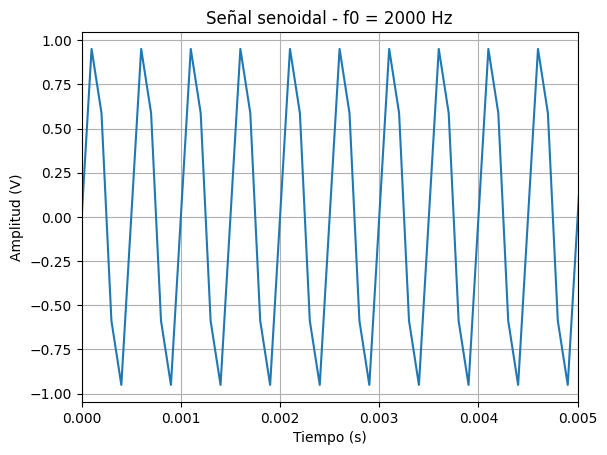

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import math

#%% Señal sinusoidal de 2 KHz

def mi_funcion_sen(vmax = 1, dc = 0, f0 = 2000, n = 1000, fs = 10000, ph=0):
    
    ts = 1 / fs
    
    tt = np.linspace (0, (n-1) * ts , n)
    
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt,xx=mi_funcion_sen()

plt.figure()

plt.title('Señal senoidal - f0 = 2000 Hz')

plt.xlim(0, 0.005) ## Muestro solo los primeros 5ms (10 ciclos). Esto debido a que si no queda como un bloque celeste y no se logra diferenciar la senoidal. 

plt.xlabel('Tiempo (s)')

plt.ylabel('Amplitud (V)')

plt.grid(True)

plt.plot(tt, xx)

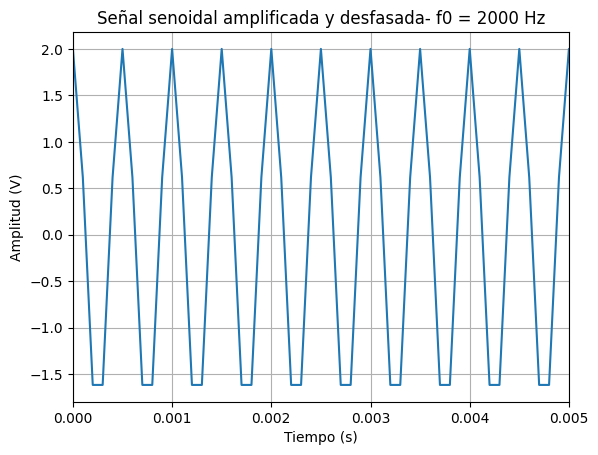

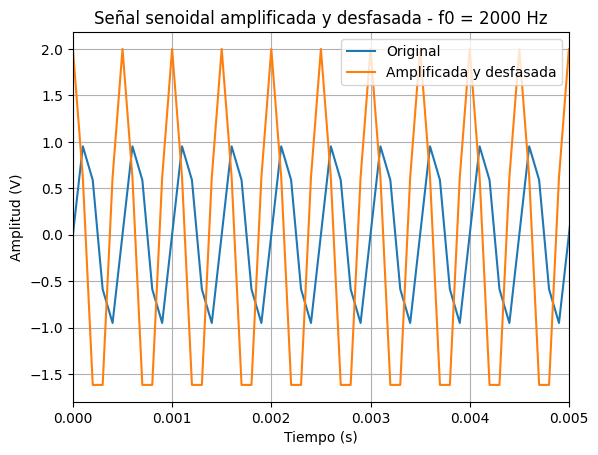

In [2]:
#%% Señal sinusoidal de 2 KHz amplificada y desfasada en π/2

def mi_funcion_sen2(vmax = 2, dc = 0, f0 = 2000, n = 1000, fs = 10000, ph= math.pi/2):
    
    ts = 1 / fs
    
    tt = np.linspace (0, (n-1) * ts , n)
    
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt,xx=mi_funcion_sen2()

plt.figure()

plt.title('Señal senoidal amplificada y desfasada- f0 = 2000 Hz')

plt.xlim(0, 0.005) ## Muestro solo los primeros 5ms (10 ciclos). Esto debido a que si no queda como un bloque celeste y no se logra diferenciar la senoidal. 

plt.xlabel('Tiempo (s)')

plt.ylabel('Amplitud (V)')

plt.grid(True)

plt.plot(tt, xx)

#Agrego un grafico de ambas funciones para que se pueda ver claramente la amplificación y el desfasaje.

plt.figure()

tt1, xx1 = mi_funcion_sen()

tt2, xx2 = mi_funcion_sen2()

plt.title('Señal senoidal amplificada y desfasada - f0 = 2000 Hz')

plt.xlim(0, 0.005)

plt.xlabel('Tiempo (s)')

plt.ylabel('Amplitud (V)')

plt.grid(True)

plt.plot(tt1, xx1, label='Original')

plt.plot(tt2, xx2, label='Amplificada y desfasada')

plt.legend()

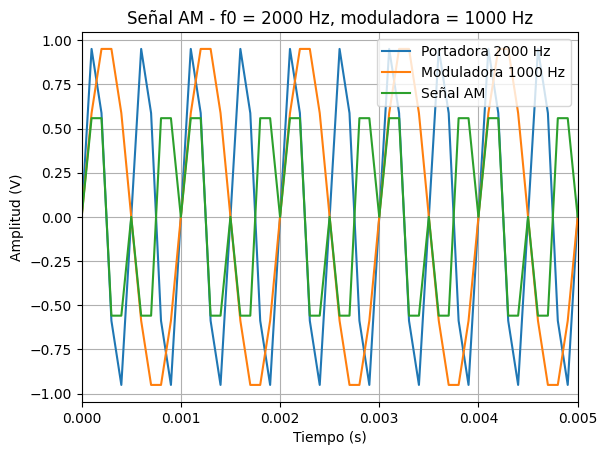

In [3]:
#%%Misma señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia.

def mi_funcion_sen_modulador(vmax = 1, dc = 0, f0 = 1000, n = 1000, fs = 10000, ph= 0):
    
    ts = 1 / fs
    
    tt = np.linspace (0, (n-1) * ts , n)
    
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt, xx_original = mi_funcion_sen()

tt, xx_moduladora = mi_funcion_sen_modulador()

xx_am = xx_original* xx_moduladora

plt.figure()

plt.plot(tt, xx_original, label='Portadora 2000 Hz')

plt.plot(tt, xx_moduladora, label='Moduladora 1000 Hz')

plt.plot(tt, xx_am, label='Señal AM')

plt.title('Señal AM - f0 = 2000 Hz, moduladora = 1000 Hz')

plt.xlim(0, 0.005)

plt.xlabel('Tiempo (s)')

plt.ylabel('Amplitud (V)')

plt.grid(True)

plt.legend()

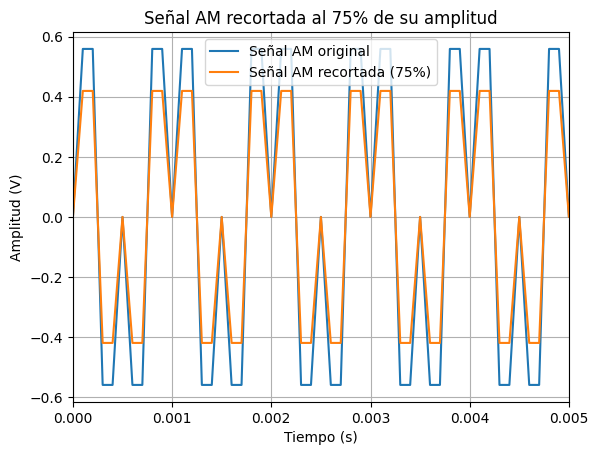

In [4]:
#%%Señal anterior recortada al 75% de su amplitud.

# Amplitud máxima de la señal AM
Amax = np.max(np.abs(xx_am))

# Nivel de recorte (75%)
Aclip = 0.75 * Amax

# Aplicar clipping
xx_am_recortada = np.clip(xx_am, -Aclip, Aclip)

plt.figure()
plt.plot(tt, xx_am, label='Señal AM original')
plt.plot(tt, xx_am_recortada, label='Señal AM recortada (75%)')
plt.title('Señal AM recortada al 75% de su amplitud')
plt.xlim(0, 0.005)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.legend()

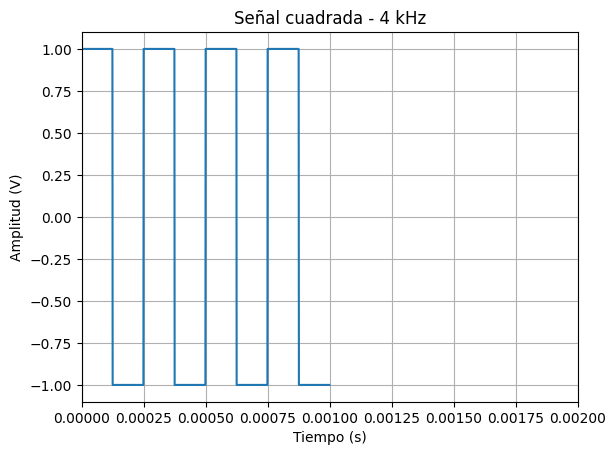

In [5]:
#%% Señal cuadrada de 4 KHz

from scipy.signal import square

def mi_funcion_cuadrada(vmax=1, dc=0, f0=4000, n=1000, fs=1000000):
    
    ts = 1 / fs
    tt = np.linspace(0, (n-1)*ts, n)
    
    xx = dc + vmax * square(2*np.pi*f0*tt)
    
    return tt, xx

tt, xx = mi_funcion_cuadrada()

plt.figure()
plt.title('Señal cuadrada - 4 kHz')
plt.xlim(0, 0.002)  # 2 ms = 8 ciclos
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt, xx)

(0.0, 0.02)

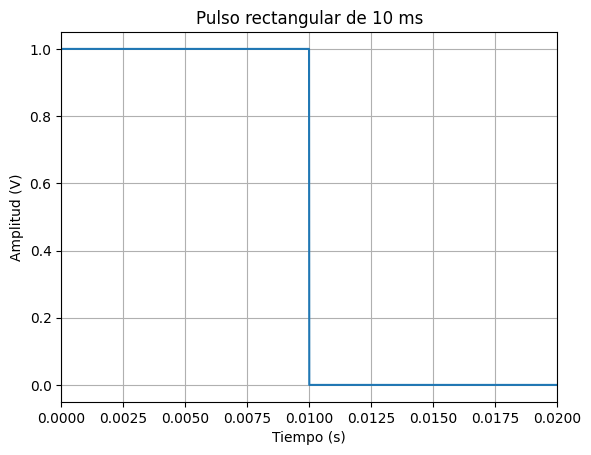

In [6]:
#%% Pulso rectangular de 10 ms

def pulso_rectangular(A=1, dur_pulso=0.01, n=2000, fs=100000):
    ts = 1 / fs
    tt = np.linspace(0, (n-1)*ts, n)

    xx = np.zeros(n)
    muestras_pulso = int(dur_pulso * fs)

    xx[:muestras_pulso] = A

    return tt, xx

tt, xx = pulso_rectangular()

plt.figure()
plt.title('Pulso rectangular de 10 ms')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt, xx)
plt.xlim(0, 0.02)  # muestro 20 ms

Ejercicio 2: 
Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

b) x[n] = (1/2)ⁿ u[n].

c) x[n] = u[n + 1] - u[n - 2].

In [1]:
from IPython.display import IFrame
IFrame("TS1_Entrega.pdf", width=800, height=500)